## Colab and Google Drive Setup

Mount Google Drive, define the project directories, install the required libraries, and verify that a CUDA GPU is available.

In [1]:
%pip install -q \
    transformers==4.56.1 \
    trl==0.17.0 \
    peft==0.19.1 \
    datasets \
    accelerate \
    evaluate \
    rouge_score \
    sacrebleu

%pip uninstall -y torchao

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.0/348.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [2]:
import torch
import peft
import transformers
import trl

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("TRL:", trl.__version__)
print("PEFT:", peft.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cpu
Transformers: 4.56.1
TRL: 0.17.0
PEFT: 0.19.1
CUDA available: False


In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# Scientific LLM Fine-Tuning with LoRA

This notebook fine-tunes an instruction-tuned language model for scientific question answering using supervised fine-tuning and Low-Rank Adaptation (LoRA).

The workflow includes:

- loading the prepared dataset,
- evaluating the original model,
- configuring LoRA,
- supervised fine-tuning,
- training diagnostics,
- held-out evaluation,
- and qualitative base-versus-LoRA comparison.

The dataset covers geospatial machine learning, environmental science, air pollution, machine learning, computer vision, and large language models.

**Author:** Milad Saeedi

## 1. Imports and Configuration

Load the fixed dataset splits created in the dataset-preparation notebook and define the model and training configuration.

In [5]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import set_seed


# --------------------------------------------------------------
# Reproducibility
# --------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)


# --------------------------------------------------------------
# Model and dataset
# --------------------------------------------------------------

MODEL_NAME = (
    "HuggingFaceTB/"
    "SmolLM2-135M-Instruct"
)

DATASET_HUB_ID = (
    "Miladsaeedi70/"
    "scientific-multitask-instructions"
)

# Final value selected during tokenizer analysis
MAX_SEQ_LENGTH = 512


# --------------------------------------------------------------
# Persistent output directories
# --------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/SFT_GRPO"
)

MODEL_OUTPUT_DIR = (
    PROJECT_ROOT
    / "models"
    / "smollm2-135m-scientific-sft-lora"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "sft_full_run"
)


if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        "Project folder was not found:\n"
        f"{PROJECT_ROOT}\n\n"
        "Mount Google Drive before running this cell."
    )


MODEL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("Model:", MODEL_NAME)
print("Dataset:", DATASET_HUB_ID)
print("Project root:", PROJECT_ROOT)
print("Model output:", MODEL_OUTPUT_DIR)
print("Results directory:", RESULTS_DIR)

Model: HuggingFaceTB/SmolLM2-135M-Instruct
Dataset: Miladsaeedi70/scientific-multitask-instructions
Project root: /content/drive/MyDrive/SFT_GRPO
Model output: /content/drive/MyDrive/SFT_GRPO/models/smollm2-135m-scientific-sft-lora
Results directory: /content/drive/MyDrive/SFT_GRPO/results/sft_full_run


In [7]:

dataset = load_dataset(
    DATASET_HUB_ID,
    token=True,
)

print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/290k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/41.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/42.0k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1260 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/158 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/158 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 1260
    })
    validation: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 158
    })
    test: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 158
    })
})


In [8]:
EXPECTED_SPLITS = {
    "train",
    "validation",
    "test",
}

if set(dataset.keys()) != EXPECTED_SPLITS:
    raise ValueError(
        f"Expected splits {EXPECTED_SPLITS}, "
        f"but found {set(dataset.keys())}."
    )


for split_name, split_dataset in dataset.items():
    print(
        f"{split_name:<10}: "
        f"{len(split_dataset):>5} examples"
    )

train     :  1260 examples
validation:   158 examples
test      :   158 examples


In [9]:
sample = dataset["train"][0]

print("ID:", sample["id"])
print("Category:", sample["category"])
print("Task:", sample["task"])
print("Difficulty:", sample["difficulty"])

for message in sample["messages"]:
    print(f"\n{message['role'].upper()}:")
    print(message["content"])

ID: researchgpt-00001
Category: Air Pollution
Task: scientific_question_answering
Difficulty: intermediate

SYSTEM:
You are ResearchGPT, a scientific research assistant.

USER:
Why must spatial autocorrelation be considered in air pollution studies?

ASSISTANT:
Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.


## 2. Runtime, Tokenizer, and Base Model

Configure the available hardware, load the tokenizer used during sequence-length analysis, and load the original model for baseline evaluation.

In [10]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")

    if torch.cuda.is_bf16_supported():
        MODEL_DTYPE = torch.bfloat16
    else:
        MODEL_DTYPE = torch.float16

elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    MODEL_DTYPE = torch.float16

else:
    DEVICE = torch.device("cpu")
    MODEL_DTYPE = torch.float32


print("Device:", DEVICE)
print("Model dtype:", MODEL_DTYPE)

Device: cpu
Model dtype: torch.float32


In [ ]:
from transformers import ( AutoModelForCausalLM, AutoTokenizer,)
tokenizer = AutoTokenizer.from_pretrained( MODEL_NAME, use_fast=True,)

if tokenizer.pad_token is None:
    if tokenizer.eos_token is None:
        raise ValueError(
            "The tokenizer has neither a pad token nor an EOS token."
        )

    tokenizer.pad_token = tokenizer.eos_token


tokenizer.padding_side = "right"

print("Tokenizer:", tokenizer.__class__.__name__)
print("Vocabulary size:", len(tokenizer))
print("Padding token:", repr(tokenizer.pad_token))
print("Padding token ID:", tokenizer.pad_token_id)
print("Padding side:", tokenizer.padding_side)

assert tokenizer.chat_template is not None

print("Chat template is available.")
print("Configured maximum sequence length:", MAX_SEQ_LENGTH)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

Tokenizer: GPT2TokenizerFast
Vocabulary size: 49152
Padding token: '<|im_end|>'
Padding token ID: 2
Padding side: right
Chat template is available.
Configured maximum sequence length: 512


In [ ]:
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE,
)

config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [ ]:

base_model = base_model.to(DEVICE)

In [ ]:
base_model.config.pad_token_id = tokenizer.pad_token_id
base_model.config.eos_token_id = tokenizer.eos_token_id

In [ ]:
base_model.eval()
base_model.config.use_cache = True

In [ ]:
total_parameters = sum(
    parameter.numel()
    for parameter in base_model.parameters()
)

print("Model loaded successfully.")
print(f"Total parameters: {total_parameters:,}")
print(
    "Model device:",
    next(base_model.parameters()).device,
)

Model loaded successfully.
Total parameters: 134,515,008
Model device: cuda:0


In [ ]:
test_messages = [
    {
        "role": "system",
        "content": (
            "You are ResearchGPT, "
            "a scientific research assistant."
        ),
    },
    {
        "role": "user",
        "content": (
            "Explain overfitting in machine learning "
            "in two concise sentences."
        ),
    },
]

In [ ]:
formatted_prompt = tokenizer.apply_chat_template(
    test_messages,
    tokenize=False,
    add_generation_prompt=True,
)

print(formatted_prompt)

<|im_start|>system
You are ResearchGPT, a scientific research assistant.<|im_end|>
<|im_start|>user
Explain overfitting in machine learning in two concise sentences.<|im_end|>
<|im_start|>assistant



In [ ]:
model_inputs = tokenizer(
    formatted_prompt,
    return_tensors="pt",
).to(DEVICE)

In [ ]:
with torch.inference_mode():
    generated_ids = base_model.generate(
        **model_inputs,
        max_new_tokens=256,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

In [ ]:
new_token_ids = generated_ids[
    0,
    model_inputs["input_ids"].shape[1]:,
]

response = tokenizer.decode(
    new_token_ids,
    skip_special_tokens=True,
).strip()

print("BASE MODEL RESPONSE:")
print(response)

BASE MODEL RESPONSE:
Overfitting occurs when a model is too complex and learns the noise in the training data, fitting the training data too closely and capturing the underlying patterns, rather than generalizing well to new data.


## 3. Generation and Baseline Predictions

Create a reusable generation function and generate predictions from the unchanged base model on the held-out test split.

In [ ]:
def generate_response(
    model,
    messages,
    tokenizer,
    max_new_tokens=256,
):
    prompt_messages = [
        message
        for message in messages
        if message["role"] != "assistant"
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_device = next(model.parameters()).device

    model_inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    ).to(model_device)

    model.eval()

    with torch.inference_mode():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    prompt_length = model_inputs["input_ids"].shape[1]

    new_token_ids = generated_ids[
        0,
        prompt_length:,
    ]

    return tokenizer.decode(
        new_token_ids,
        skip_special_tokens=True,
    ).strip()

In [ ]:
test_example = dataset["test"][0]

base_response = generate_response(
    model=base_model,
    messages=test_example["messages"],
    tokenizer=tokenizer,
    max_new_tokens=256,
)

reference_response = next(
    message["content"]
    for message in test_example["messages"]
    if message["role"] == "assistant"
)

user_instruction = next(
    message["content"]
    for message in test_example["messages"]
    if message["role"] == "user"
)

print("USER:")
print(user_instruction)

print("\nREFERENCE:")
print(reference_response)

print("\nBASE MODEL:")
print(base_response)

USER:
How does GPS accuracy affect pollution mapping?

REFERENCE:
GPS errors can assign a measurement to the wrong street, buffer, or land-use feature, especially in urban canyons. Such misalignment blurs hotspots and introduces error into spatial predictors and maps.

BASE MODEL:
GPS accuracy plays a crucial role in pollution mapping by providing precise location information to ensure accurate and reliable data collection. When GPS signals are transmitted from a source, they can be received at a receiver or sensor, which converts the signal into a digital representation of the location. This digital representation is then used to create a map of the area where pollution is present.

However, GPS accuracy can vary depending on factors such as the distance between the transmitter and the receiver, the type of receiver used, and the quality of the signal. In some cases, GPS signals may be affected by atmospheric conditions, such as cloud cover or fog, which can reduce their accuracy. Add

In [ ]:
baseline_evaluation_dataset = dataset["test"]

print(
    "Baseline evaluation examples:",
    len(baseline_evaluation_dataset),
)

Baseline evaluation examples: 158


During debugging, I use this:

In [ ]:
#baseline_evaluation_dataset = dataset["test"].select(range(min(10, len(dataset["test"]))))

In [ ]:
from tqdm.auto import tqdm


baseline_records = []

for example in tqdm(
    baseline_evaluation_dataset,
    desc="Generating base-model predictions",
):
    prediction = generate_response(
        model=base_model,
        messages=example["messages"],
        tokenizer=tokenizer,
        max_new_tokens=256,
    )

    instruction = next(
        message["content"]
        for message in example["messages"]
        if message["role"] == "user"
    )

    reference = next(
        message["content"]
        for message in example["messages"]
        if message["role"] == "assistant"
    )

    baseline_records.append(
        {
            "id": example["id"],
            "task": example["task"],
            "difficulty": example["difficulty"],
            "instruction": instruction,
            "reference": reference,
            "base_prediction": prediction,
        }
    )

Generating base-model predictions:   0%|          | 0/158 [00:00<?, ?it/s]

In [ ]:
baseline_predictions_df = pd.DataFrame(
    baseline_records
)

baseline_predictions_df.head()

,id,task,difficulty,instruction,reference,base_prediction
0,researchgpt-00013,scientific_question_answering,intermediate,How does GPS accuracy affect pollution mapping?,GPS errors can assign a measurement to the wro...,GPS accuracy plays a crucial role in pollution...
1,researchgpt-00016,scientific_question_answering,intermediate,Why is NO₂ considered a useful indicator of tr...,NO₂ is closely associated with fuel combustion...,Nitrous oxide (NO) is a potent greenhouse gas ...
2,researchgpt-00027,scientific_question_answering,intermediate,How are road-network features engineered for m...,Road-network features can include road length ...,Road network features are engineered to improv...
3,researchgpt-00035,scientific_question_answering,intermediate,What metrics should be used to evaluate spatia...,"Common metrics include MAE, RMSE, R², bias, an...","When evaluating spatial prediction models, sev..."
4,researchgpt-00037,scientific_question_answering,intermediate,How can SHAP explain predictions made by envir...,SHAP assigns each feature a contribution relat...,SHAP (Simultaneous Human-AI Interaction) is an...


In [ ]:
assert len(baseline_predictions_df) == len(
    baseline_evaluation_dataset
)

assert baseline_predictions_df["id"].is_unique

print(
    "Generated predictions:",
    len(baseline_predictions_df),
)

print(
    "Empty predictions:",
    baseline_predictions_df[
        "base_prediction"
    ].str.strip().eq("").sum(),
)

Generated predictions: 158
Empty predictions: 0


In [ ]:
BASELINE_PREDICTIONS_PATH = (
    RESULTS_DIR / "baseline_predictions.jsonl"
)

baseline_predictions_df.to_json(
    BASELINE_PREDICTIONS_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)

print(
    "Saved baseline predictions to:",
    BASELINE_PREDICTIONS_PATH.resolve(),
)

Saved baseline predictions to: /content/drive/MyDrive/SFT_GRPO/results/full_run/baseline_predictions.jsonl


In [ ]:
del base_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()
elif torch.backends.mps.is_available():
    torch.mps.empty_cache()

print("Baseline model removed from memory.")

Baseline model removed from memory.


## 4. Prepare the SFT Dataset and LoRA Configuration

Convert the conversational dataset into prompt-completion format so training loss is calculated on the assistant response, then define the LoRA adapter configuration.

In [ ]:
def create_prompt_completion(example):
    """
    Separate one conversation into:

    prompt:
        system and user messages

    completion:
        assistant response
    """

    prompt = [
        message
        for message in example["messages"]
        if message["role"] != "assistant"
    ]

    completion = [
        message
        for message in example["messages"]
        if message["role"] == "assistant"
    ]

    if not prompt:
        raise ValueError(
            f"Example {example['id']} has no prompt messages."
        )

    if len(completion) != 1:
        raise ValueError(
            f"Example {example['id']} must contain exactly "
            f"one assistant response; found {len(completion)}."
        )

    return {
        "prompt": prompt,
        "completion": completion,
    }

In [ ]:
sft_dataset = dataset.map(
    create_prompt_completion,
    remove_columns=dataset["train"].column_names,
    desc="Creating prompt-completion dataset",
)

sft_dataset

DatasetDict({
    train: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 1260
    })
    validation: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 158
    })
    test: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 158
    })
})

In [ ]:
sft_sample = sft_dataset["train"][0]

print("PROMPT:")

for message in sft_sample["prompt"]:
    print(f"\n{message['role'].upper()}:")
    print(message["content"])

print("\n" + "=" * 80)
print("COMPLETION:")

for message in sft_sample["completion"]:
    print(f"\n{message['role'].upper()}:")
    print(message["content"])

PROMPT:

SYSTEM:
You are ResearchGPT, a scientific research assistant.

USER:
Why must spatial autocorrelation be considered in air pollution studies?

COMPLETION:

ASSISTANT:
Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.


In [ ]:
for split_name, split_dataset in sft_dataset.items():
    invalid_examples = 0

    for example in split_dataset:
        prompt_roles = [
            message["role"]
            for message in example["prompt"]
        ]

        completion_roles = [
            message["role"]
            for message in example["completion"]
        ]

        if prompt_roles != ["system", "user"]:
            invalid_examples += 1

        if completion_roles != ["assistant"]:
            invalid_examples += 1

    print(
        f"{split_name:<10}: "
        f"{len(split_dataset):>5} examples, "
        f"invalid={invalid_examples}"
    )

    assert invalid_examples == 0

print("All SFT examples are valid.")

train     :  1260 examples, invalid=0
validation:   158 examples, invalid=0
test      :   158 examples, invalid=0
All SFT examples are valid.


In [ ]:
formatted_prompt = tokenizer.apply_chat_template(
    sft_sample["prompt"],
    tokenize=False,
    add_generation_prompt=True,
)

formatted_completion = tokenizer.apply_chat_template(
    sft_sample["completion"],
    tokenize=False,
    add_generation_prompt=False,
)

print("FORMATTED PROMPT:")
print(formatted_prompt)

print("\nFORMATTED COMPLETION:")
print(formatted_completion)

FORMATTED PROMPT:
<|im_start|>system
You are ResearchGPT, a scientific research assistant.<|im_end|>
<|im_start|>user
Why must spatial autocorrelation be considered in air pollution studies?<|im_end|>
<|im_start|>assistant


FORMATTED COMPLETION:
<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>assistant
Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.<|im_end|>



In [ ]:
from peft import LoraConfig, TaskType


lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,

    r=16,
    lora_alpha=32,
    lora_dropout=0.05,

    target_modules="all-linear",
    bias="none",
)

lora_config

LoraConfig(task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules='all-linear', exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)

In [ ]:
train_dataset = sft_dataset["train"]
validation_dataset = sft_dataset["validation"]

print("Training examples:", len(train_dataset))
print("Validation examples:", len(validation_dataset))

Training examples: 1260
Validation examples: 158


### small dataset for testing

In [ ]:
# Temporary small subsets for testing the pipeline
# USE_SMALL_DATASET = True

# SMALL_TRAIN_SIZE = 32
# SMALL_VALIDATION_SIZE = 8


# if USE_SMALL_DATASET:
#     train_dataset = (
#         sft_dataset["train"]
#         .shuffle(seed=SEED)
#         .select(
#             range(
#                 min(
#                     SMALL_TRAIN_SIZE,
#                     len(sft_dataset["train"]),
#                 )
#             )
#         )
#     )

#     validation_dataset = (
#         sft_dataset["validation"]
#         .shuffle(seed=SEED)
#         .select(
#             range(
#                 min(
#                     SMALL_VALIDATION_SIZE,
#                     len(sft_dataset["validation"]),
#                 )
#             )
#         )
#     )

# else:
#     train_dataset = sft_dataset["train"]
#     validation_dataset = sft_dataset["validation"]


# print("Training examples:", len(train_dataset))
# print("Validation examples:", len(validation_dataset))

## 5. Configure the SFT Trainer

Define the supervised fine-tuning configuration, initialize the model with LoRA adapters, and verify that loss is computed only on assistant-completion tokens.

In [ ]:
import peft
import transformers
import trl

print("Transformers:", transformers.__version__)
print("TRL:", trl.__version__)
print("PEFT:", peft.__version__)

Transformers: 4.56.1
TRL: 0.17.0
PEFT: 0.19.1


In [ ]:
USE_BF16 = (
    torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)

USE_FP16 = (
    torch.cuda.is_available()
    and not USE_BF16
)

if USE_BF16:
    TRAINING_DTYPE = "bfloat16"
elif USE_FP16:
    TRAINING_DTYPE = "float16"
else:
    TRAINING_DTYPE = "float32"

print("BF16:", USE_BF16)
print("FP16:", USE_FP16)
print("Training dtype:", TRAINING_DTYPE)

BF16: True
FP16: False
Training dtype: bfloat16


In [ ]:
from trl import SFTConfig, SFTTrainer


training_args = SFTConfig(
    output_dir=str(MODEL_OUTPUT_DIR),

    seed=SEED,
    data_seed=SEED,

    # Dataset processing
    max_length=MAX_SEQ_LENGTH,
    completion_only_loss=True,
    packing=False,

    # Full training
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,

    # Reduce activation memory
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={
        "use_reentrant": False,
    },

    # Optimization
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type="linear",
    max_grad_norm=1.0,
    optim="adamw_torch",

    # Evaluate and save each epoch
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,

    # Logging
    logging_strategy="steps",
    logging_steps=10,
    report_to="none",

    # GPU precision
    bf16=USE_BF16,
    fp16=USE_FP16,

    dataloader_pin_memory=True,

    model_init_kwargs={
        "torch_dtype": TRAINING_DTYPE,
    },
)

In [ ]:
effective_batch_size = (
    training_args.per_device_train_batch_size
    * training_args.gradient_accumulation_steps
)

print("Effective training batch size:", effective_batch_size)
print("Maximum sequence length:", training_args.max_length)

Effective training batch size: 16
Maximum sequence length: 512


In [ ]:
trainer = SFTTrainer(
    model=MODEL_NAME,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    processing_class=tokenizer,
    peft_config=lora_config,
)

trainer.model.print_trainable_parameters()

Converting train dataset to ChatML:   0%|          | 0/1260 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/1260 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1260 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1260 [00:00<?, ? examples/s]

Converting eval dataset to ChatML:   0%|          | 0/158 [00:00<?, ? examples/s]

Applying chat template to eval dataset:   0%|          | 0/158 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/158 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/158 [00:00<?, ? examples/s]

trainable params: 4,884,480 || all params: 139,399,488 || trainable%: 3.5039


In [ ]:
trainer.model.print_trainable_parameters()

trainable params: 4,884,480 || all params: 139,399,488 || trainable%: 3.5039


In [ ]:
trainable_parameters = sum(
    parameter.numel()
    for parameter in trainer.model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in trainer.model.parameters()
)

trainable_percentage = (
    100 * trainable_parameters / total_parameters
)

print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters:     {total_parameters:,}")
print(f"Trainable percentage: {trainable_percentage:.2f}%")

Trainable parameters: 4,884,480
Total parameters:     139,399,488
Trainable percentage: 3.50%


In [ ]:
processed_example = trainer.train_dataset[0]

print("Processed fields:")
print(processed_example.keys())

Processed fields:
dict_keys(['prompt', 'completion', 'input_ids', 'attention_mask', 'completion_mask'])


In [ ]:
sample_batch = trainer.data_collator(
    [processed_example]
)

input_ids = sample_batch["input_ids"][0]
labels = sample_batch["labels"][0]
attention_mask = sample_batch["attention_mask"][0]

print("Input shape:", input_ids.shape)
print("Label shape:", labels.shape)

Input shape: torch.Size([73])
Label shape: torch.Size([73])


In [ ]:
loss_mask = labels != -100
ignored_mask = labels == -100

print("Tokens used for loss:", int(loss_mask.sum()))
print("Tokens ignored:", int(ignored_mask.sum()))

assert loss_mask.any(), (
    "No tokens are included in the training loss."
)

assert ignored_mask.any(), (
    "Prompt tokens do not appear to be masked."
)

Tokens used for loss: 35
Tokens ignored: 38


In [ ]:
full_text = tokenizer.decode(
    input_ids[attention_mask.bool()],
    skip_special_tokens=False,
)

print("FULL TRAINING EXAMPLE:")
print(full_text)

FULL TRAINING EXAMPLE:
<|im_start|>system
You are ResearchGPT, a scientific research assistant.<|im_end|>
<|im_start|>user
Why must spatial autocorrelation be considered in air pollution studies?<|im_end|>
<|im_start|>assistant
Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.<|im_end|>



In [ ]:
supervised_text = tokenizer.decode(
    input_ids[loss_mask],
    skip_special_tokens=False,
)

print("\nTEXT USED FOR LOSS:")
print(supervised_text)


TEXT USED FOR LOSS:
Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.<|im_end|>



In [ ]:
train_result = trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,2.635800,2.710362
2,2.468500,2.621476
3,2.415700,2.602435


In [ ]:
train_result

TrainOutput(global_step=237, training_loss=2.572592638715913, metrics={'train_runtime': 1037.1927, 'train_samples_per_second': 3.644, 'train_steps_per_second': 0.229, 'total_flos': 348124707726336.0, 'train_loss': 2.572592638715913})

## 6. Save the Trained LoRA Adapter

Save the trained LoRA adapter, tokenizer, training metrics, and configuration. The adapter contains only the fine-tuned LoRA parameters and is loaded later on top of the original base model.

In [ ]:
FINAL_ADAPTER_DIR = (
    MODEL_OUTPUT_DIR / "final_adapter"
)

FINAL_ADAPTER_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Adapter directory:",
    FINAL_ADAPTER_DIR.resolve(),
)

Adapter directory: /content/drive/MyDrive/SFT_GRPO/models/smollm2-scientific-lora-final/final_adapter


In [ ]:
trainer.save_model(
    str(FINAL_ADAPTER_DIR)
)

tokenizer.save_pretrained(
    str(FINAL_ADAPTER_DIR)
)

print(
    "LoRA adapter saved to:",
    FINAL_ADAPTER_DIR.resolve(),
)

LoRA adapter saved to: /content/drive/MyDrive/SFT_GRPO/models/smollm2-scientific-lora-final/final_adapter


In [ ]:
saved_files = sorted(
    path.name
    for path in FINAL_ADAPTER_DIR.iterdir()
)

print("Saved files:")

for filename in saved_files:
    print("-", filename)

Saved files:
- README.md
- adapter_config.json
- adapter_model.safetensors
- chat_template.jinja
- merges.txt
- special_tokens_map.json
- tokenizer.json
- tokenizer_config.json
- training_args.bin
- vocab.json


In [ ]:
training_summary = {
    "base_model": MODEL_NAME,
    "adapter_directory": str(
        FINAL_ADAPTER_DIR
    ),
    "training_examples": len(
        train_dataset
    ),
    "validation_examples": len(
        validation_dataset
    ),
    "epochs": training_args.num_train_epochs,
    "global_steps": train_result.global_step,
    "training_loss": train_result.training_loss,
    "max_sequence_length": (
        training_args.max_length
    ),
    "learning_rate": (
        training_args.learning_rate
    ),
    "train_batch_size": (
        training_args
        .per_device_train_batch_size
    ),
    "gradient_accumulation_steps": (
        training_args
        .gradient_accumulation_steps
    ),
    "lora_rank": lora_config.r,
    "lora_alpha": lora_config.lora_alpha,
    "lora_dropout": (
        lora_config.lora_dropout
    ),
    "lora_target_modules": (
        lora_config.target_modules
    ),
}

training_summary

{'base_model': 'HuggingFaceTB/SmolLM2-135M-Instruct',
 'adapter_directory': '/content/drive/MyDrive/SFT_GRPO/models/smollm2-scientific-lora-final/final_adapter',
 'training_examples': 1260,
 'validation_examples': 158,
 'epochs': 3,
 'global_steps': 237,
 'training_loss': 2.572592638715913,
 'max_sequence_length': 512,
 'learning_rate': 0.0001,
 'train_batch_size': 2,
 'gradient_accumulation_steps': 8,
 'lora_rank': 16,
 'lora_alpha': 32,
 'lora_dropout': 0.05,
 'lora_target_modules': {'down_proj',
  'gate_proj',
  'k_proj',
  'o_proj',
  'q_proj',
  'up_proj',
  'v_proj'}}

In [ ]:
import json


RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TRAINING_SUMMARY_PATH = (
    RESULTS_DIR / "training_summary.json"
)

with open(
    TRAINING_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        training_summary,
        file,
        indent=2,
        default=str,
    )

print(
    "Training summary saved to:",
    TRAINING_SUMMARY_PATH.resolve(),
)

Training summary saved to: /content/drive/MyDrive/SFT_GRPO/results/full_run/training_summary.json


## 7. Reload the LoRA Adapter for Inference

Reload the saved LoRA adapter on top of the original base model and verify that it can generate responses for held-out test examples. The model is loaded in inference mode so gradients are disabled and no further training is performed.

In [ ]:
lora_model = trainer.model

lora_model.eval()
lora_model.config.use_cache = True

if hasattr(
    lora_model,
    "gradient_checkpointing_disable",
):
    lora_model.gradient_checkpointing_disable()

for parameter in lora_model.parameters():
    parameter.requires_grad_(False)

print(
    "LoRA model device:",
    next(lora_model.parameters()).device,
)

LoRA model device: cuda:0


In [ ]:
import gc


if getattr(trainer, "optimizer", None) is not None:
    trainer.optimizer = None

if getattr(trainer, "lr_scheduler", None) is not None:
    trainer.lr_scheduler = None


del trainer

gc.collect()
torch.cuda.empty_cache()

print("Training objects cleared.")

Training objects cleared.


In [ ]:
model_devices = {
    parameter.device
    for parameter in lora_model.parameters()
}

print("Model devices:", model_devices)

assert all(
    device.type == "cuda"
    for device in model_devices
), "Some model parameters are not on CUDA."

Model devices: {device(type='cuda', index=0)}


In [ ]:
model_devices = {
    parameter.device
    for parameter in lora_model.parameters()
}

print("Model devices:", model_devices)


Model devices: {device(type='cuda', index=0)}


In [ ]:
inference_tokenizer = tokenizer

if inference_tokenizer.pad_token is None:
    inference_tokenizer.pad_token = (
        inference_tokenizer.eos_token
    )

inference_tokenizer.padding_side = "right"

In [ ]:
test_example = dataset["test"][0]

lora_response = generate_response(
    model=lora_model,
    messages=test_example["messages"],
    tokenizer=inference_tokenizer,
    max_new_tokens=256,
)

print(lora_response)

GPS accuracy can provide information about the location of pollutants and their movement, but it is not sufficient on its own to determine whether a particular area is polluted. Other environmental factors may be at play.


## 8. Generate LoRA Predictions on the Test Set

Generate responses from the fine-tuned LoRA model for every example in the held-out test split. The predictions are saved with their example IDs, task labels, instructions, and reference responses for later quantitative and qualitative evaluation.

In [ ]:
evaluation_dataset = dataset["test"]

print("Test examples:", len(evaluation_dataset))

Test examples: 158


In [ ]:
from tqdm.auto import tqdm


lora_prediction_records = []

for example in tqdm(
    evaluation_dataset,
    desc="Generating LoRA predictions",
):
    lora_prediction = generate_response(
        model=lora_model,
        messages=example["messages"],
        tokenizer=inference_tokenizer,
        max_new_tokens=256,
    )

    user_instruction = next(
        message["content"]
        for message in example["messages"]
        if message["role"] == "user"
    )

    reference_response = next(
        message["content"]
        for message in example["messages"]
        if message["role"] == "assistant"
    )

    lora_prediction_records.append(
        {
            "id": example["id"],
            "category": example["category"],
            "task": example["task"],
            "difficulty": example["difficulty"],
            "instruction": user_instruction,
            "reference": reference_response,
            "lora_prediction": lora_prediction,
        }
    )

Generating LoRA predictions:   0%|          | 0/158 [00:00<?, ?it/s]

In [ ]:
lora_predictions_df = pd.DataFrame(
    lora_prediction_records
)

print("Generated predictions:", len(lora_predictions_df))

lora_predictions_df.head()

Generated predictions: 158


,id,category,task,difficulty,instruction,reference,lora_prediction
0,researchgpt-00013,Air Pollution,scientific_question_answering,intermediate,How does GPS accuracy affect pollution mapping?,GPS errors can assign a measurement to the wro...,GPS accuracy can provide information about the...
1,researchgpt-00016,Air Pollution,scientific_question_answering,intermediate,Why is NO₂ considered a useful indicator of tr...,NO₂ is closely associated with fuel combustion...,NO₂ reacts with ozone and other pollutants in ...
2,researchgpt-00027,Geospatial Machine Learning,scientific_question_answering,intermediate,How are road-network features engineered for m...,Road-network features can include road length ...,Road network features are designed to capture ...
3,researchgpt-00035,Geospatial Machine Learning,scientific_question_answering,intermediate,What metrics should be used to evaluate spatia...,"Common metrics include MAE, RMSE, R², bias, an...",The accuracy of spatial prediction models depe...
4,researchgpt-00037,Machine Learning,scientific_question_answering,intermediate,How can SHAP explain predictions made by envir...,SHAP assigns each feature a contribution relat...,SHAP predicts the location of an object or per...


In [ ]:
assert len(lora_predictions_df) == len(
    evaluation_dataset
), "The number of predictions does not match the test dataset."

assert lora_predictions_df[
    "id"
].is_unique, "Prediction IDs are not unique."

empty_predictions = (
    lora_predictions_df["lora_prediction"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Unique prediction IDs:", lora_predictions_df["id"].nunique())
print("Empty predictions:", empty_predictions)

Unique prediction IDs: 158
Empty predictions: 0


In [ ]:
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LORA_PREDICTIONS_PATH = (
    RESULTS_DIR / "lora_predictions.jsonl"
)

lora_predictions_df.to_json(
    LORA_PREDICTIONS_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)

print(
    "LoRA predictions saved to:",
    LORA_PREDICTIONS_PATH.resolve(),
)

LoRA predictions saved to: /content/drive/MyDrive/SFT_GRPO/results/full_run/lora_predictions.jsonl


In [ ]:
example_index = 0
row = lora_predictions_df.iloc[example_index]

print("TASK:")
print(row["task"])

print("\nUSER INSTRUCTION:")
print(row["instruction"])

print("\nREFERENCE RESPONSE:")
print(row["reference"])

print("\nLORA MODEL RESPONSE:")
print(row["lora_prediction"])

TASK:
scientific_question_answering

USER INSTRUCTION:
How does GPS accuracy affect pollution mapping?

REFERENCE RESPONSE:
GPS errors can assign a measurement to the wrong street, buffer, or land-use feature, especially in urban canyons. Such misalignment blurs hotspots and introduces error into spatial predictors and maps.

LORA MODEL RESPONSE:
GPS accuracy can provide information about the location of pollutants and their movement, but it is not sufficient on its own to determine whether a particular area is polluted. Other environmental factors may be at play.


## 9. Compare Base and LoRA Predictions

Combine the base-model and LoRA-model predictions using their unique test-example IDs. This ensures that both models are evaluated on exactly the same held-out examples.

In [ ]:
lora_predictions_df = pd.DataFrame(
    lora_prediction_records
)

assert len(lora_predictions_df) == len(
    evaluation_dataset
), "Prediction count does not match the evaluation dataset."

assert lora_predictions_df["id"].is_unique, (
    "LoRA prediction IDs are not unique."
)

empty_lora_predictions = (
    lora_predictions_df["lora_prediction"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("LoRA predictions:", len(lora_predictions_df))
print("Empty predictions:", empty_lora_predictions)

lora_predictions_df.head()

LoRA predictions: 158
Empty predictions: 0


,id,category,task,difficulty,instruction,reference,lora_prediction
0,researchgpt-00013,Air Pollution,scientific_question_answering,intermediate,How does GPS accuracy affect pollution mapping?,GPS errors can assign a measurement to the wro...,GPS accuracy can provide information about the...
1,researchgpt-00016,Air Pollution,scientific_question_answering,intermediate,Why is NO₂ considered a useful indicator of tr...,NO₂ is closely associated with fuel combustion...,NO₂ reacts with ozone and other pollutants in ...
2,researchgpt-00027,Geospatial Machine Learning,scientific_question_answering,intermediate,How are road-network features engineered for m...,Road-network features can include road length ...,Road network features are designed to capture ...
3,researchgpt-00035,Geospatial Machine Learning,scientific_question_answering,intermediate,What metrics should be used to evaluate spatia...,"Common metrics include MAE, RMSE, R², bias, an...",The accuracy of spatial prediction models depe...
4,researchgpt-00037,Machine Learning,scientific_question_answering,intermediate,How can SHAP explain predictions made by envir...,SHAP assigns each feature a contribution relat...,SHAP predicts the location of an object or per...


In [ ]:
LORA_PREDICTIONS_PATH = (
    RESULTS_DIR / "lora_predictions.jsonl"
)

lora_predictions_df.to_json(
    LORA_PREDICTIONS_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)

print(
    "LoRA predictions saved to:",
    LORA_PREDICTIONS_PATH.resolve(),
)

LoRA predictions saved to: /content/drive/MyDrive/SFT_GRPO/results/full_run/lora_predictions.jsonl


In [ ]:
BASE_PREDICTIONS_PATH = (
    RESULTS_DIR / "baseline_predictions.jsonl"
)

baseline_predictions_df = pd.read_json(
    BASE_PREDICTIONS_PATH,
    lines=True,
)

print(
    "Base-model predictions:",
    len(baseline_predictions_df),
)

baseline_predictions_df.head()

Base-model predictions: 158


,id,task,difficulty,instruction,reference,base_prediction
0,researchgpt-00013,scientific_question_answering,intermediate,How does GPS accuracy affect pollution mapping?,GPS errors can assign a measurement to the wro...,GPS accuracy plays a crucial role in pollution...
1,researchgpt-00016,scientific_question_answering,intermediate,Why is NO₂ considered a useful indicator of tr...,NO₂ is closely associated with fuel combustion...,Nitrous oxide (NO) is a potent greenhouse gas ...
2,researchgpt-00027,scientific_question_answering,intermediate,How are road-network features engineered for m...,Road-network features can include road length ...,Road network features are engineered to improv...
3,researchgpt-00035,scientific_question_answering,intermediate,What metrics should be used to evaluate spatia...,"Common metrics include MAE, RMSE, R², bias, an...","When evaluating spatial prediction models, sev..."
4,researchgpt-00037,scientific_question_answering,intermediate,How can SHAP explain predictions made by envir...,SHAP assigns each feature a contribution relat...,SHAP (Simultaneous Human-AI Interaction) is an...


In [ ]:
required_base_columns = {
    "id",
    "base_prediction",
}

missing_base_columns = (
    required_base_columns
    - set(baseline_predictions_df.columns)
)

if missing_base_columns:
    raise ValueError(
        "Missing base prediction columns: "
        f"{sorted(missing_base_columns)}"
    )

In [ ]:
print("Base predictions:", len(baseline_predictions_df))
print("LoRA predictions:", len(lora_predictions_df))

base_ids = set(baseline_predictions_df["id"])
lora_ids = set(lora_predictions_df["id"])

print("Base IDs:", len(base_ids))
print("LoRA IDs:", len(lora_ids))
print("IDs only in base:", len(base_ids - lora_ids))
print("IDs only in LoRA:", len(lora_ids - base_ids))

assert base_ids == lora_ids, (
    "Base and LoRA predictions do not cover "
    "the same test examples."
)

Base predictions: 158
LoRA predictions: 158
Base IDs: 158
LoRA IDs: 158
IDs only in base: 0
IDs only in LoRA: 0


In [ ]:
comparison_df = lora_predictions_df.merge(
    baseline_predictions_df[
        [
            "id",
            "base_prediction",
        ]
    ],
    on="id",
    how="inner",
    validate="one_to_one",
)

assert len(comparison_df) == len(
    dataset["test"]
)

print("Matched examples:", len(comparison_df))

Matched examples: 158


In [ ]:
print("Base predictions:", len(baseline_predictions_df))
print("LoRA predictions:", len(lora_predictions_df))
print("Matched examples:", len(comparison_df))

assert len(comparison_df) == len(
    baseline_predictions_df
), (
    "Some base-model predictions do not have "
    "matching LoRA predictions."
)

assert comparison_df["id"].is_unique

Base predictions: 158
LoRA predictions: 158
Matched examples: 158


In [ ]:
comparison_df = comparison_df[
    [
        "id",
        "category",
        "task",
        "difficulty",
        "instruction",
        "reference",
        "base_prediction",
        "lora_prediction",
    ]
]

comparison_df.head()

,id,category,task,difficulty,instruction,reference,base_prediction,lora_prediction
0,researchgpt-00013,Air Pollution,scientific_question_answering,intermediate,How does GPS accuracy affect pollution mapping?,GPS errors can assign a measurement to the wro...,GPS accuracy plays a crucial role in pollution...,GPS accuracy can provide information about the...
1,researchgpt-00016,Air Pollution,scientific_question_answering,intermediate,Why is NO₂ considered a useful indicator of tr...,NO₂ is closely associated with fuel combustion...,Nitrous oxide (NO) is a potent greenhouse gas ...,NO₂ reacts with ozone and other pollutants in ...
2,researchgpt-00027,Geospatial Machine Learning,scientific_question_answering,intermediate,How are road-network features engineered for m...,Road-network features can include road length ...,Road network features are engineered to improv...,Road network features are designed to capture ...
3,researchgpt-00035,Geospatial Machine Learning,scientific_question_answering,intermediate,What metrics should be used to evaluate spatia...,"Common metrics include MAE, RMSE, R², bias, an...","When evaluating spatial prediction models, sev...",The accuracy of spatial prediction models depe...
4,researchgpt-00037,Machine Learning,scientific_question_answering,intermediate,How can SHAP explain predictions made by envir...,SHAP assigns each feature a contribution relat...,SHAP (Simultaneous Human-AI Interaction) is an...,SHAP predicts the location of an object or per...


In [ ]:
missing_base_ids = set(
    lora_predictions_df["id"]
) - set(
    baseline_predictions_df["id"]
)

print(
    "LoRA examples without base predictions:",
    len(missing_base_ids),
)

LoRA examples without base predictions: 0


In [ ]:
example_index = 0
row = comparison_df.iloc[example_index]

print("TASK:")
print(row["task"])

print("\nDIFFICULTY:")
print(row["difficulty"])

print("\nUSER INSTRUCTION:")
print(row["instruction"])

print("\nREFERENCE RESPONSE:")
print(row["reference"])

print("\nBASE MODEL RESPONSE:")
print(row["base_prediction"])

print("\nLORA MODEL RESPONSE:")
print(row["lora_prediction"])

TASK:
scientific_question_answering

DIFFICULTY:
intermediate

USER INSTRUCTION:
How does GPS accuracy affect pollution mapping?

REFERENCE RESPONSE:
GPS errors can assign a measurement to the wrong street, buffer, or land-use feature, especially in urban canyons. Such misalignment blurs hotspots and introduces error into spatial predictors and maps.

BASE MODEL RESPONSE:
GPS accuracy plays a crucial role in pollution mapping by providing precise location information to ensure accurate and reliable data collection. When GPS signals are transmitted from a source, they can be received at a receiver or sensor, which converts the signal into a digital representation of the location. This digital representation is then used to create a map of the area where pollution is present.

However, GPS accuracy can vary depending on factors such as the distance between the transmitter and the receiver, the type of receiver used, and the quality of the signal. In some cases, GPS signals may be affecte

In [ ]:
COMPARISON_PATH = (
    RESULTS_DIR / "base_vs_lora_predictions.jsonl"
)

comparison_df.to_json(
    COMPARISON_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)

print(
    "Comparison saved to:",
    COMPARISON_PATH.resolve(),
)

Comparison saved to: /content/drive/MyDrive/SFT_GRPO/results/full_run/base_vs_lora_predictions.jsonl


## 10. Quantitative Evaluation with ROUGE

Evaluate the base and LoRA model responses against the reference answers using ROUGE-1, ROUGE-2, and ROUGE-L.

ROUGE measures lexical overlap between generated and reference responses. It is useful for comparing models consistently, although it does not fully measure scientific correctness, reasoning quality, or semantic equivalence.

In [ ]:
import evaluate


rouge_metric = evaluate.load("rouge")

print("ROUGE metric loaded.")

ROUGE metric loaded.


In [ ]:
text_columns = [
    "reference",
    "base_prediction",
    "lora_prediction",
]

for column in text_columns:
    comparison_df[column] = (
        comparison_df[column]
        .fillna("")
        .astype(str)
        .str.strip()
    )

print(
    "Empty base predictions:",
    comparison_df["base_prediction"].eq("").sum(),
)

print(
    "Empty LoRA predictions:",
    comparison_df["lora_prediction"].eq("").sum(),
)

Empty base predictions: 0
Empty LoRA predictions: 0


In [ ]:
base_rouge = rouge_metric.compute(
    predictions=comparison_df[
        "base_prediction"
    ].tolist(),
    references=comparison_df[
        "reference"
    ].tolist(),
    use_stemmer=True,
)

lora_rouge = rouge_metric.compute(
    predictions=comparison_df[
        "lora_prediction"
    ].tolist(),
    references=comparison_df[
        "reference"
    ].tolist(),
    use_stemmer=True,
)

In [ ]:
print("Base-model ROUGE:")
print(base_rouge)

print("\nLoRA-model ROUGE:")
print(lora_rouge)

Base-model ROUGE:
{'rouge1': np.float64(0.18455287720213837), 'rouge2': np.float64(0.035616803214152434), 'rougeL': np.float64(0.12812426359876072), 'rougeLsum': np.float64(0.1498657439611148)}

LoRA-model ROUGE:
{'rouge1': np.float64(0.29311955607178286), 'rouge2': np.float64(0.0663888643745705), 'rougeL': np.float64(0.21270630674012386), 'rougeLsum': np.float64(0.2356825876631573)}


In [ ]:
rouge_summary = pd.DataFrame(
    {
        "Base Model": {
            "ROUGE-1": base_rouge["rouge1"],
            "ROUGE-2": base_rouge["rouge2"],
            "ROUGE-L": base_rouge["rougeL"],
            "ROUGE-Lsum": base_rouge["rougeLsum"],
        },
        "LoRA Model": {
            "ROUGE-1": lora_rouge["rouge1"],
            "ROUGE-2": lora_rouge["rouge2"],
            "ROUGE-L": lora_rouge["rougeL"],
            "ROUGE-Lsum": lora_rouge["rougeLsum"],
        },
    }
)

rouge_summary["Difference"] = (
    rouge_summary["LoRA Model"]
    - rouge_summary["Base Model"]
)

rouge_summary

,Base Model,LoRA Model,Difference
ROUGE-1,0.184553,0.293120,0.108567
ROUGE-2,0.035617,0.066389,0.030772
ROUGE-L,0.128124,0.212706,0.084582
ROUGE-Lsum,0.149866,0.235683,0.085817


In [ ]:
rouge_summary.round(4)

,Base Model,LoRA Model,Difference
ROUGE-1,0.1846,0.2931,0.1086
ROUGE-2,0.0356,0.0664,0.0308
ROUGE-L,0.1281,0.2127,0.0846
ROUGE-Lsum,0.1499,0.2357,0.0858


In [ ]:
comparison_df["reference_word_count"] = (
    comparison_df["reference"]
    .str.split()
    .str.len()
)

comparison_df["base_word_count"] = (
    comparison_df["base_prediction"]
    .str.split()
    .str.len()
)

comparison_df["lora_word_count"] = (
    comparison_df["lora_prediction"]
    .str.split()
    .str.len()
)

In [ ]:
length_summary = pd.DataFrame(
    {
        "Reference": comparison_df[
            "reference_word_count"
        ].describe(),
        "Base Model": comparison_df[
            "base_word_count"
        ].describe(),
        "LoRA Model": comparison_df[
            "lora_word_count"
        ].describe(),
    }
)

length_summary.round(2)

,Reference,Base Model,LoRA Model
count,158.00,158.00,158.00
mean,39.08,144.51,40.51
std,27.52,65.90,27.35
min,10.00,18.00,10.00
25%,22.25,82.50,21.00
50%,30.00,177.50,34.50
75%,43.00,199.00,47.00
max,117.00,221.00,150.00


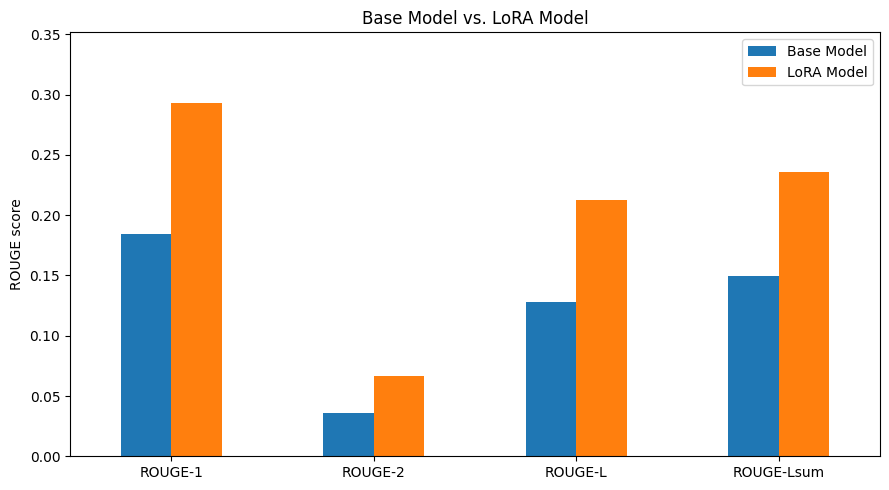

In [ ]:
import matplotlib.pyplot as plt


plot_df = (
    rouge_summary[
        ["Base Model", "LoRA Model"]
    ]
    .reset_index()
    .rename(columns={"index": "Metric"})
)

ax = plot_df.plot(
    x="Metric",
    kind="bar",
    figsize=(9, 5),
)

ax.set_ylabel("ROUGE score")
ax.set_xlabel("")
ax.set_title("Base Model vs. LoRA Model")
ax.set_ylim(
    0,
    max(
        plot_df["Base Model"].max(),
        plot_df["LoRA Model"].max(),
    )
    * 1.2,
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
ROUGE_RESULTS_PATH = (
    RESULTS_DIR / "rouge_evaluation.csv"
)

rouge_summary.to_csv(
    ROUGE_RESULTS_PATH
)

print(
    "ROUGE results saved to:",
    ROUGE_RESULTS_PATH.resolve(),
)

ROUGE results saved to: /content/drive/MyDrive/SFT_GRPO/results/full_run/rouge_evaluation.csv


## 11. Evaluate Performance by Task

Calculate ROUGE scores separately for each scientific task. This identifies which task types improved after LoRA fine-tuning and which tasks may require more training examples or additional refinement.

Per-task results should be interpreted carefully when a task contains only a small number of test examples.

In [ ]:
task_counts = (
    comparison_df["task"]
    .value_counts()
    .sort_index()
    .rename_axis("task")
    .reset_index(name="test_examples")
)

task_counts

,task,test_examples
0,bullet_generation,19
1,code_generation,10
2,concept_explanation,20
3,data_analysis,20
4,method_comparison,20
5,scientific_question_answering,27
6,summarization,21
7,technical_simplification,21


In [ ]:
per_task_records = []

for task_name, task_df in comparison_df.groupby(
    "task",
    sort=True,
):
    base_task_rouge = rouge_metric.compute(
        predictions=task_df[
            "base_prediction"
        ].tolist(),
        references=task_df[
            "reference"
        ].tolist(),
        use_stemmer=True,
    )

    lora_task_rouge = rouge_metric.compute(
        predictions=task_df[
            "lora_prediction"
        ].tolist(),
        references=task_df[
            "reference"
        ].tolist(),
        use_stemmer=True,
    )

    per_task_records.append(
        {
            "task": task_name,
            "test_examples": len(task_df),

            "base_rouge1": (
                base_task_rouge["rouge1"]
            ),
            "lora_rouge1": (
                lora_task_rouge["rouge1"]
            ),

            "base_rouge2": (
                base_task_rouge["rouge2"]
            ),
            "lora_rouge2": (
                lora_task_rouge["rouge2"]
            ),

            "base_rougeL": (
                base_task_rouge["rougeL"]
            ),
            "lora_rougeL": (
                lora_task_rouge["rougeL"]
            ),
        }
    )

In [ ]:
per_task_rouge_df = pd.DataFrame(
    per_task_records
)

per_task_rouge_df[
    "rouge1_difference"
] = (
    per_task_rouge_df["lora_rouge1"]
    - per_task_rouge_df["base_rouge1"]
)

per_task_rouge_df[
    "rouge2_difference"
] = (
    per_task_rouge_df["lora_rouge2"]
    - per_task_rouge_df["base_rouge2"]
)

per_task_rouge_df[
    "rougeL_difference"
] = (
    per_task_rouge_df["lora_rougeL"]
    - per_task_rouge_df["base_rougeL"]
)

per_task_rouge_df.round(4)

,task,test_examples,base_rouge1,lora_rouge1,base_rouge2,lora_rouge2,base_rougeL,lora_rougeL,rouge1_difference,rouge2_difference,rougeL_difference
0,bullet_generation,19,0.1086,0.1965,0.0139,0.0183,0.0733,0.1317,0.0879,0.0044,0.0584
1,code_generation,10,0.1993,0.3530,0.0693,0.1490,0.1544,0.3113,0.1537,0.0796,0.1569
2,concept_explanation,20,0.2648,0.3410,0.0408,0.0751,0.1383,0.1956,0.0762,0.0343,0.0572
3,data_analysis,20,0.1446,0.2674,0.0175,0.0470,0.1064,0.1788,0.1228,0.0295,0.0724
4,method_comparison,20,0.1829,0.3327,0.0411,0.0828,0.1277,0.2193,0.1498,0.0417,0.0916
5,scientific_question_answering,27,0.1191,0.2754,0.0246,0.0611,0.0928,0.2166,0.1563,0.0364,0.1238
6,summarization,21,0.2120,0.2603,0.0336,0.0450,0.1565,0.2047,0.0484,0.0114,0.0483
7,technical_simplification,21,0.2695,0.3486,0.0621,0.0874,0.1965,0.2825,0.0791,0.0253,0.0860


In [ ]:
task_improvement_df = (
    per_task_rouge_df
    .sort_values(
        "rougeL_difference",
        ascending=False,
    )
    .reset_index(drop=True)
)

task_improvement_df[
    [
        "task",
        "test_examples",
        "base_rougeL",
        "lora_rougeL",
        "rougeL_difference",
    ]
].round(4)

,task,test_examples,base_rougeL,lora_rougeL,rougeL_difference
0,code_generation,10,0.1544,0.3113,0.1569
1,scientific_question_answering,27,0.0928,0.2166,0.1238
2,method_comparison,20,0.1277,0.2193,0.0916
3,technical_simplification,21,0.1965,0.2825,0.0860
4,data_analysis,20,0.1064,0.1788,0.0724
5,bullet_generation,19,0.0733,0.1317,0.0584
6,concept_explanation,20,0.1383,0.1956,0.0572
7,summarization,21,0.1565,0.2047,0.0483


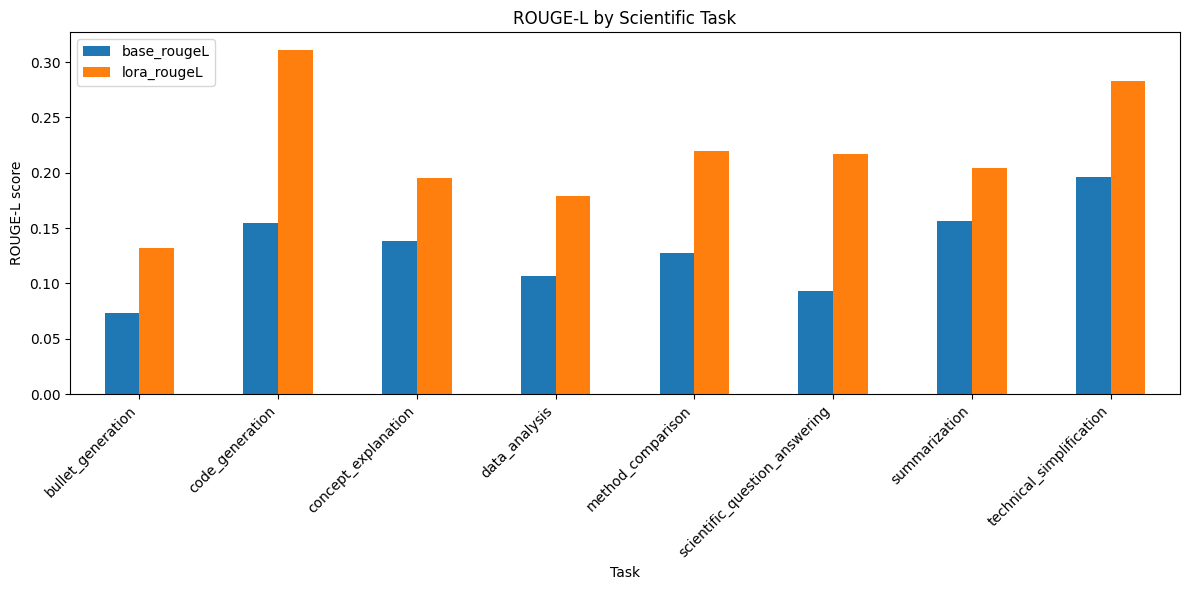

In [ ]:
plot_task_df = (
    per_task_rouge_df[
        [
            "task",
            "base_rougeL",
            "lora_rougeL",
        ]
    ]
    .set_index("task")
)

ax = plot_task_df.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.set_title(
    "ROUGE-L by Scientific Task"
)

ax.set_xlabel("Task")
ax.set_ylabel("ROUGE-L score")

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

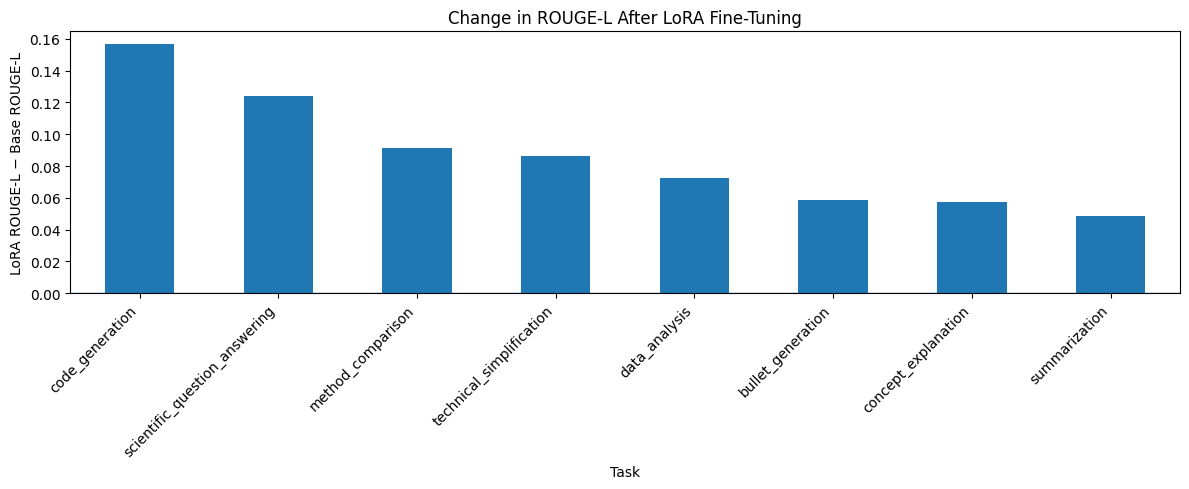

In [ ]:
improvement_plot_df = (
    task_improvement_df[
        [
            "task",
            "rougeL_difference",
        ]
    ]
    .set_index("task")
)

ax = improvement_plot_df.plot(
    kind="bar",
    figsize=(12, 5),
    legend=False,
)

ax.axhline(
    y=0,
    linewidth=1,
)

ax.set_title(
    "Change in ROUGE-L After LoRA Fine-Tuning"
)

ax.set_xlabel("Task")
ax.set_ylabel(
    "LoRA ROUGE-L − Base ROUGE-L"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

In [ ]:
PER_TASK_RESULTS_PATH = (
    RESULTS_DIR
    / "per_task_rouge_evaluation.csv"
)

per_task_rouge_df.to_csv(
    PER_TASK_RESULTS_PATH,
    index=False,
)

print(
    "Per-task results saved to:",
    PER_TASK_RESULTS_PATH.resolve(),
)

Per-task results saved to: /content/drive/MyDrive/SFT_GRPO/results/full_run/per_task_rouge_evaluation.csv


## 12. Qualitative Error Analysis

Inspect examples where LoRA fine-tuning produced the largest improvement or decline relative to the base model.

ROUGE-L is calculated separately for each response so that individual examples can be ranked. Because ROUGE measures text overlap rather than scientific correctness, these examples should also be reviewed manually for relevance, clarity, factual accuracy, and task completion.

In [ ]:
def calculate_example_rouge_l(
    prediction,
    reference,
):
    score = rouge_metric.compute(
        predictions=[prediction],
        references=[reference],
        use_stemmer=True,
    )

    return score["rougeL"]

In [ ]:
comparison_df["base_rougeL"] = comparison_df.apply(
    lambda row: calculate_example_rouge_l(
        prediction=row["base_prediction"],
        reference=row["reference"],
    ),
    axis=1,
)

comparison_df["lora_rougeL"] = comparison_df.apply(
    lambda row: calculate_example_rouge_l(
        prediction=row["lora_prediction"],
        reference=row["reference"],
    ),
    axis=1,
)

comparison_df["rougeL_difference"] = (
    comparison_df["lora_rougeL"]
    - comparison_df["base_rougeL"]
)

In [ ]:
largest_improvements = (
    comparison_df
    .sort_values(
        "rougeL_difference",
        ascending=False,
    )
    .head(3)
)

largest_improvements[
    [
        "id",
        "task",
        "difficulty",
        "base_rougeL",
        "lora_rougeL",
        "rougeL_difference",
    ]
].round(4)

,id,task,difficulty,base_rougeL,lora_rougeL,rougeL_difference
149,researchgpt-01502,code_generation,easy,0.1226,0.5926,0.4700
101,researchgpt-01000,technical_simplification,easy,0.0842,0.3830,0.2988
95,researchgpt-00946,technical_simplification,easy,0.1345,0.4286,0.2941


In [ ]:
for _, row in largest_improvements.iterrows():
    print("=" * 100)
    print("EXAMPLE ID:", row["id"])
    print("TASK:", row["task"])
    print(
        "ROUGE-L CHANGE:",
        round(row["rougeL_difference"], 4),
    )

    print("\nINSTRUCTION:")
    print(row["instruction"])

    print("\nREFERENCE:")
    print(row["reference"])

    print("\nBASE MODEL:")
    print(row["base_prediction"])

    print("\nLORA MODEL:")
    print(row["lora_prediction"])

    print()

EXAMPLE ID: researchgpt-01502
TASK: code_generation
ROUGE-L CHANGE: 0.47

INSTRUCTION:
Write Python code to split feature and target arrays into training and testing sets.

REFERENCE:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.arange(40).reshape(20, 2)
y = np.array([0, 1] * 10)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print(X_train.shape, X_test.shape)

BASE MODEL:
Here's a Python function that splits the feature and target arrays into training and testing sets:

```python
def split_features_and_targets(feature_array, target_array):
    training_set = []
    testing_set = []

    for i in range(len(feature_array)):
        if feature_array[i] == target_array[i]:
            training_set.append(feature_array[i])
        else:
            testing_set.append(target_array[i])

    return training_set, testing_set
```

This function iterates through each feature in the

In [ ]:
largest_declines = (
    comparison_df
    .sort_values(
        "rougeL_difference",
        ascending=True,
    )
    .head(3)
)

largest_declines[
    [
        "id",
        "task",
        "difficulty",
        "base_rougeL",
        "lora_rougeL",
        "rougeL_difference",
    ]
].round(4)

,id,task,difficulty,base_rougeL,lora_rougeL,rougeL_difference
57,researchgpt-00580,summarization,intermediate,0.2642,0.1818,-0.0823
49,researchgpt-00483,summarization,intermediate,0.2353,0.1622,-0.0731
55,researchgpt-00552,summarization,intermediate,0.1860,0.1429,-0.0432


In [ ]:
for _, row in largest_declines.iterrows():
    print("=" * 100)
    print("EXAMPLE ID:", row["id"])
    print("TASK:", row["task"])
    print(
        "ROUGE-L CHANGE:",
        round(row["rougeL_difference"], 4),
    )

    print("\nINSTRUCTION:")
    print(row["instruction"])

    print("\nREFERENCE:")
    print(row["reference"])

    print("\nBASE MODEL:")
    print(row["base_prediction"])

    print("\nLORA MODEL:")
    print(row["lora_prediction"])

    print()

EXAMPLE ID: researchgpt-00580
TASK: summarization
ROUGE-L CHANGE: -0.0823

INSTRUCTION:
Summarize the following faithfully paraphrased abstract:

This study analyzes how surface PM2.5 and satellite aerosol optical depth vary across regions, seasons, and meteorological conditions in China. It shows that their relationship is not constant and that humidity, vertical structure, and aerosol properties affect satellite-based estimation.

REFERENCE:
AOD–PM2.5 relationships vary substantially across space, season, and atmospheric conditions.

BASE MODEL:
This study analyzes how surface PM2.5 and satellite aerosol optical depth vary across regions, seasons, and meteorological conditions in China. It demonstrates that their relationship is not constant and that humidity, vertical structure, and aerosol properties affect satellite-based estimation.

LORA MODEL:
Surface PM2.5 and satellite-derived aerosol optical depth can be used to estimate regional variability of PM2.5 and aerosols.

EXAMPLE I

In [ ]:
EXAMPLE_RESULTS_PATH = (
    RESULTS_DIR
    / "example_level_evaluation.csv"
)

comparison_df.to_csv(
    EXAMPLE_RESULTS_PATH,
    index=False,
)

print(
    "Example-level results saved to:",
    EXAMPLE_RESULTS_PATH.resolve(),
)

Example-level results saved to: /content/drive/MyDrive/SFT_GRPO/results/full_run/example_level_evaluation.csv


## 13. Final Results Summary and Conclusions

Summarize the training configuration, overall evaluation results, per-task performance, and qualitative findings.

The base and LoRA models were evaluated on the same held-out test examples. ROUGE measures lexical similarity to the reference responses, so the results should be interpreted together with the qualitative error analysis. A higher ROUGE score does not automatically guarantee greater scientific correctness.

In [ ]:
training_configuration = pd.DataFrame(
    {
        "Setting": [
            "Base model",
            "Training examples",
            "Validation examples",
            "Epochs",
            "Global training steps",
            "Training loss",
            "Maximum sequence length",
            "Learning rate",
            "LoRA rank",
            "LoRA alpha",
            "LoRA dropout",
        ],
        "Value": [
            MODEL_NAME,
            len(train_dataset),
            len(validation_dataset),
            training_args.num_train_epochs,
            train_result.global_step,
            round(train_result.training_loss, 4),
            training_args.max_length,
            training_args.learning_rate,
            lora_config.r,
            lora_config.lora_alpha,
            lora_config.lora_dropout,
        ],
    }
)

training_configuration

,Setting,Value
0,Base model,HuggingFaceTB/SmolLM2-135M-Instruct
1,Training examples,1260
2,Validation examples,158
3,Epochs,3
4,Global training steps,237
5,Training loss,2.5726
6,Maximum sequence length,512
7,Learning rate,0.0001
8,LoRA rank,16
9,LoRA alpha,32


In [ ]:
final_rouge_summary = (
    rouge_summary
    .copy()
    .round(4)
)

final_rouge_summary

,Base Model,LoRA Model,Difference
ROUGE-1,0.1846,0.2931,0.1086
ROUGE-2,0.0356,0.0664,0.0308
ROUGE-L,0.1281,0.2127,0.0846
ROUGE-Lsum,0.1499,0.2357,0.0858


In [ ]:
best_task = task_improvement_df.iloc[0]
weakest_task = task_improvement_df.iloc[-1]

print("Largest ROUGE-L improvement:")
print("Task:", best_task["task"])
print(
    "Change:",
    round(best_task["rougeL_difference"], 4),
)

print("\nLargest ROUGE-L decline:")
print("Task:", weakest_task["task"])
print(
    "Change:",
    round(weakest_task["rougeL_difference"], 4),
)

Largest ROUGE-L improvement:
Task: code_generation
Change: 0.1569

Largest ROUGE-L decline:
Task: summarization
Change: 0.0483


In [ ]:
improved_tasks = (
    per_task_rouge_df[
        "rougeL_difference"
    ] > 0
).sum()

declined_tasks = (
    per_task_rouge_df[
        "rougeL_difference"
    ] < 0
).sum()

unchanged_tasks = (
    per_task_rouge_df[
        "rougeL_difference"
    ] == 0
).sum()

improved_examples = (
    comparison_df[
        "rougeL_difference"
    ] > 0
).sum()

declined_examples = (
    comparison_df[
        "rougeL_difference"
    ] < 0
).sum()

print("Tasks improved:", improved_tasks)
print("Tasks declined:", declined_tasks)
print("Tasks unchanged:", unchanged_tasks)

print("\nExamples improved:", improved_examples)
print("Examples declined:", declined_examples)

Tasks improved: 8
Tasks declined: 0
Tasks unchanged: 0

Examples improved: 146
Examples declined: 12


In [ ]:
final_results = {
    "base_model": MODEL_NAME,
    "test_examples": len(comparison_df),

    "training_loss": float(
        train_result.training_loss
    ),

    "base_rouge1": float(
        base_rouge["rouge1"]
    ),
    "lora_rouge1": float(
        lora_rouge["rouge1"]
    ),

    "base_rouge2": float(
        base_rouge["rouge2"]
    ),
    "lora_rouge2": float(
        lora_rouge["rouge2"]
    ),

    "base_rougeL": float(
        base_rouge["rougeL"]
    ),
    "lora_rougeL": float(
        lora_rouge["rougeL"]
    ),

    "rougeL_change": float(
        lora_rouge["rougeL"]
        - base_rouge["rougeL"]
    ),

    "tasks_improved": int(improved_tasks),
    "tasks_declined": int(declined_tasks),
    "examples_improved": int(
        improved_examples
    ),
    "examples_declined": int(
        declined_examples
    ),

    "largest_task_improvement": (
        best_task["task"]
    ),
    "largest_task_decline": (
        weakest_task["task"]
    ),
}

final_results

{'base_model': 'HuggingFaceTB/SmolLM2-135M-Instruct',
 'test_examples': 158,
 'training_loss': 2.572592638715913,
 'base_rouge1': 0.18455287720213837,
 'lora_rouge1': 0.29311955607178286,
 'base_rouge2': 0.035616803214152434,
 'lora_rouge2': 0.0663888643745705,
 'base_rougeL': 0.12812426359876072,
 'lora_rougeL': 0.21270630674012386,
 'rougeL_change': 0.08458204314136314,
 'tasks_improved': 8,
 'tasks_declined': 0,
 'examples_improved': 146,
 'examples_declined': 12,
 'largest_task_improvement': 'code_generation',
 'largest_task_decline': 'summarization'}

In [ ]:
FINAL_RESULTS_PATH = (
    RESULTS_DIR / "final_results_summary.json"
)

with open(
    FINAL_RESULTS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_results,
        file,
        indent=2,
        default=str,
    )

print(
    "Final results saved to:",
    FINAL_RESULTS_PATH.resolve(),
)

Final results saved to: /content/drive/MyDrive/SFT_GRPO/results/full_run/final_results_summary.json


### Conclusions

LoRA fine-tuning improved the performance of `HuggingFaceTB/SmolLM2-135M-Instruct` on the held-out scientific instruction test set.

- The model was fine-tuned on **1,260 training examples** for **3 epochs**, with a final training loss of **2.5726**.
- The LoRA model achieved a **ROUGE-1 score of 0.2931**, compared with **0.1846** for the base model.
- ROUGE-2 increased from **0.0356 to 0.0664**.
- ROUGE-L increased from **0.1281 to 0.2127**, an absolute improvement of **0.0846** and a relative improvement of approximately **66%**.
- All **8 scientific task categories** improved in average ROUGE-L after fine-tuning.
- The strongest task-level improvement occurred for **code generation**, where ROUGE-L increased by **0.1569**.
- **Summarization** showed the smallest task-level improvement, with a ROUGE-L increase of **0.0483**.
- At the individual-example level, **146 of 158 test examples (92.4%)** improved, while **12 examples (7.6%)** declined.
- The average LoRA response length was **40.5 words**, close to the reference average of **39.1 words**. In contrast, the base model averaged **144.5 words**, indicating that fine-tuning produced more concise and reference-aligned responses.
- Qualitative inspection showed particularly strong improvements for code-generation and technical-simplification examples. Some summarization examples remained weaker, suggesting that concise information selection could benefit from additional targeted training data.

Overall, LoRA fine-tuning substantially improved response relevance, conciseness, and alignment with the expected scientific task formats while updating only a small portion of the model parameters.

ROUGE measures lexical overlap rather than factual accuracy or scientific reasoning. Therefore, these results should be interpreted together with the qualitative analysis, and future evaluation could include semantic similarity, factuality assessment, and expert review.

## 14. Publish the SFT LoRA Adapter to Hugging Face

Upload the trained SFT LoRA adapter and tokenizer to the Hugging Face Hub. The repository stores the lightweight adapter rather than duplicating the complete base model.

In [ ]:
HF_REPO_ID = (
    "Miladsaeedi70/"
    "smollm2-135m-scientific-sft-lora"
)

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from google.colab import userdata
from huggingface_hub import HfApi, whoami


HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError(
        "HF_TOKEN was not found in Colab Secrets."
    )

# Remove accidental spaces or line breaks
HF_TOKEN = HF_TOKEN.strip()

if not HF_TOKEN.startswith("hf_"):
    raise ValueError(
        "HF_TOKEN does not appear to be a valid Hugging Face token."
    )


# Confirm that this exact token works
account = whoami(token=HF_TOKEN)

print("Authenticated as:", account["name"])

assert account["name"].lower() == "miladsaeedi70"

Authenticated as: Miladsaeedi70


In [ ]:
from huggingface_hub import HfApi

HF_REPO_ID = (
    "Miladsaeedi70/"
    "smollm2-135m-scientific-sft-lora"
)

api = HfApi(token=HF_TOKEN)

api.create_repo(
    repo_id=HF_REPO_ID,
    repo_type="model",
    exist_ok=True,
)

api.upload_folder(
    folder_path=str(FINAL_ADAPTER_DIR),
    repo_id=HF_REPO_ID,
    repo_type="model",
    commit_message="Upload scientific SFT LoRA adapter",
)

print(
    "Uploaded to:",
    f"https://huggingface.co/{HF_REPO_ID}",
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter/training_args.bin:   3%|2         |   177B / 6.29kB            

  ...adapter_model.safetensors:   3%|2         |  554kB / 19.6MB            

Uploaded to: https://huggingface.co/Miladsaeedi70/smollm2-135m-scientific-sft-lora


In [ ]:
import torch

from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer


BASE_MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"
ADAPTER_ID = "Miladsaeedi70/smollm2-135m-scientific-sft-lora"

dtype = (
    torch.bfloat16
    if torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
    else torch.float16
    if torch.cuda.is_available()
    else torch.float32
)

tokenizer = AutoTokenizer.from_pretrained(ADAPTER_ID)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=dtype,
)

model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_ID,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)
model.eval()

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/368 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/19.6M [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 576, padding_idx=2)
        (layers): ModuleList(
          (0-29): 30 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=576, out_features=576, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=576, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=576, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lo

In [ ]:
messages = [
    {
        "role": "system",
        "content": (
            "You are a scientific research assistant. "
            "Provide concise, accurate, and clearly structured answers."
        ),
    },
    {
        "role": "user",
        "content": (
            "Explain the difference between random cross-validation "
            "and spatial cross-validation."
        ),
    },
]

prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(
    prompt,
    return_tensors="pt",
).to(device)

with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=160,
        do_sample=False,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id,
    )

generated_ids = output_ids[
    0,
    inputs["input_ids"].shape[1]:
]

response = tokenizer.decode(
    generated_ids,
    skip_special_tokens=True,
)

print(response)

Random cross-validation is an iterative evaluation technique that combines multiple validation sets to estimate the performance of each model on unseen data. Spatial cross-validation uses geographic locations as independent validation samples for each training set. The choice depends on whether you want to evaluate models across different regions or use them in conjunction with other datasets.
